In [136]:
import torch
from torch import nn
import matplotlib.pyplot as plt



torch.__version__

'2.11.0+cpu'

In [137]:
# create a dataset
weight = 0.7
bias = 0.3

start = 0.
end = 2.
step = 0.02

x = torch.arange(start, end, step).unsqueeze(dim=1)
y = x*weight + bias

In [138]:
x[:10], y[:10], len(x), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 100,
 100)

In [139]:
# split data - train and test

train = int(0.8 * len(x))
x_train, y_train = x[:train], y[:train]
x_test, y_test = x[train:], y[train:]

In [140]:
print('test data :', len(x_test),  len(y_test))
print('train data :', len(x_train), len(y_train))

test data : 20 20
train data : 80 80


In [141]:
x_train

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800],
        [0.2000],
        [0.2200],
        [0.2400],
        [0.2600],
        [0.2800],
        [0.3000],
        [0.3200],
        [0.3400],
        [0.3600],
        [0.3800],
        [0.4000],
        [0.4200],
        [0.4400],
        [0.4600],
        [0.4800],
        [0.5000],
        [0.5200],
        [0.5400],
        [0.5600],
        [0.5800],
        [0.6000],
        [0.6200],
        [0.6400],
        [0.6600],
        [0.6800],
        [0.7000],
        [0.7200],
        [0.7400],
        [0.7600],
        [0.7800],
        [0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800],
        [1.0000],
        [1.0200],
        [1.0400],
        [1.0600],
        [1.0800],
        [1

In [142]:
y_train

tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260],
        [0.4400],
        [0.4540],
        [0.4680],
        [0.4820],
        [0.4960],
        [0.5100],
        [0.5240],
        [0.5380],
        [0.5520],
        [0.5660],
        [0.5800],
        [0.5940],
        [0.6080],
        [0.6220],
        [0.6360],
        [0.6500],
        [0.6640],
        [0.6780],
        [0.6920],
        [0.7060],
        [0.7200],
        [0.7340],
        [0.7480],
        [0.7620],
        [0.7760],
        [0.7900],
        [0.8040],
        [0.8180],
        [0.8320],
        [0.8460],
        [0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860],
        [1.0000],
        [1.0140],
        [1.0280],
        [1.0420],
        [1.0560],
        [1

In [143]:
from prompt_toolkit.shortcuts.progress_bar import Label
def plot_predictions(train_data = x_train,
                     train_labels = y_train,
                     test_data = x_test,
                     test_labels = y_test,
                     predictions = None):
  """
  Plots training data, test data and compares predictions.
  """

  plt.figure(figsize=(10,7))
  plt.scatter(train_data, train_labels, c='b', s=4 , label = 'Training data')
  plt.scatter(test_data, test_labels, c='y', s=4 , label = 'Testing data')




  if predictions is not None:
    plt.scatter(test_data, predictions, c = 'r', s = 4, label = 'Predictions')

  plt.legend(prop={'size': 14});



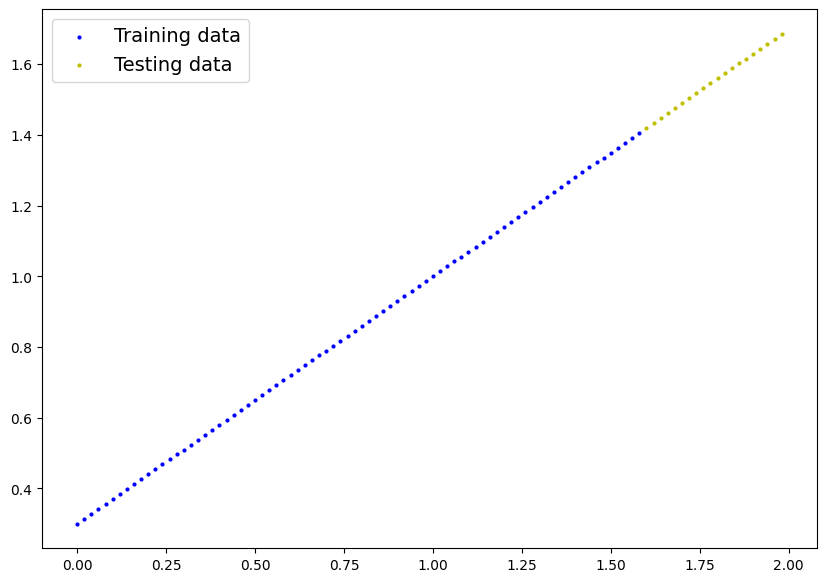

In [144]:
plot_predictions();

In [145]:
# linear regression

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad= True,
                                            dtype = torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad= True,
                                         dtype = torch.float))


  def forward(self, x: torch.Tensor) -> torch.Tensor:
      return self.weights*x + self.bias


In [146]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()

In [147]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [148]:
with torch.inference_mode():
  #Bu blok, PyTorch'a gradyan hesaplamasını (gradient tracking) devre dışı bırakmasını söyler.
  #Tahmin yaparken modelin ağırlıklarını güncellememiz gerekmediği için gradyan takibini kapatmak hafızadan tasarruf sağlar ve işlemin daha hızlı çalışmasını sağlar.
  y_preds = model_0(x_test)

# you can also do something similar with torch.inference_mode()
with torch.no_grad():
  y_preds = model_0(x_test)


y_preds

tensor([[0.6675],
        [0.6742],
        [0.6810],
        [0.6877],
        [0.6944],
        [0.7012],
        [0.7079],
        [0.7147],
        [0.7214],
        [0.7281],
        [0.7349],
        [0.7416],
        [0.7483],
        [0.7551],
        [0.7618],
        [0.7685],
        [0.7753],
        [0.7820],
        [0.7887],
        [0.7955]])

In [149]:
y_test

tensor([[1.4200],
        [1.4340],
        [1.4480],
        [1.4620],
        [1.4760],
        [1.4900],
        [1.5040],
        [1.5180],
        [1.5320],
        [1.5460],
        [1.5600],
        [1.5740],
        [1.5880],
        [1.6020],
        [1.6160],
        [1.6300],
        [1.6440],
        [1.6580],
        [1.6720],
        [1.6860]])

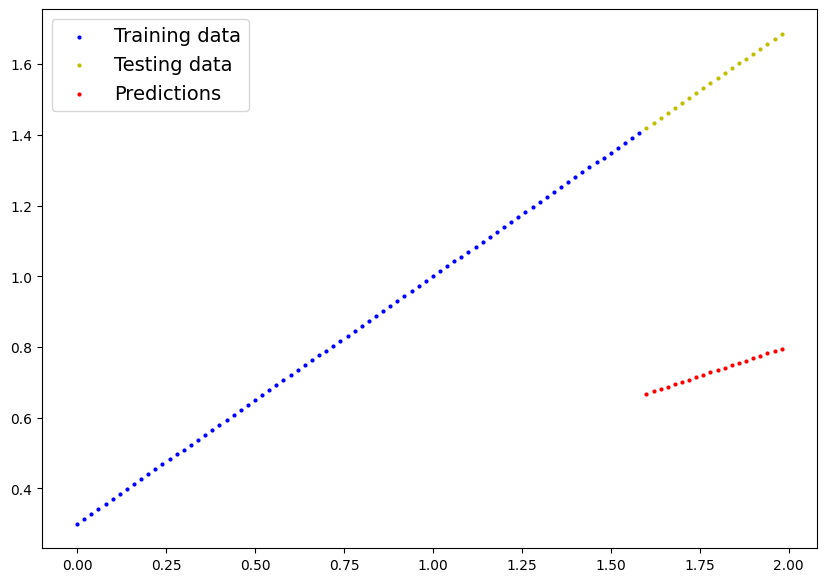

In [150]:
plot_predictions(predictions= y_preds)

In [151]:
#loss function
loss_fn = nn.L1Loss()

# optimizer
optimizer = torch.optim.SGD(params= model_0.parameters(),
                            lr=0.01 )

In [152]:
epochs = 200

epoch_count = []
loss_values = []
test_loss_values = []

for epoch in range(epochs):
    model_0.train()

    y_preds = model_0(x_train)

    loss = loss_fn(y_preds, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_0.eval()

    with torch.inference_mode():
        test_pred = model_0(x_test)

        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss.item())
        test_loss_values.append(test_loss.item())
        print(f"Epoch : {epoch} | Loss : {loss.item()} | Test Loss: {test_loss.item()}")

print(model_0.state_dict())

Epoch : 0 | Loss : 0.4582051634788513 | Test Loss: 0.79737389087677
Epoch : 10 | Loss : 0.29579514265060425 | Test Loss: 0.5559636950492859
Epoch : 20 | Loss : 0.13775773346424103 | Test Loss: 0.3183403015136719
Epoch : 30 | Loss : 0.05683191865682602 | Test Loss: 0.1473972052335739
Epoch : 40 | Loss : 0.038264136761426926 | Test Loss: 0.07959795743227005
Epoch : 50 | Loss : 0.02902190014719963 | Test Loss: 0.056470006704330444
Epoch : 60 | Loss : 0.019925223663449287 | Test Loss: 0.038054417818784714
Epoch : 70 | Loss : 0.010832054540514946 | Test Loss: 0.01963883638381958
Epoch : 80 | Loss : 0.0019744564779102802 | Test Loss: 0.0046954988501966
Epoch : 90 | Loss : 0.011621467769145966 | Test Loss: 0.0046954988501966
Epoch : 100 | Loss : 0.011621467769145966 | Test Loss: 0.0046954988501966
Epoch : 110 | Loss : 0.011621467769145966 | Test Loss: 0.0046954988501966
Epoch : 120 | Loss : 0.011621467769145966 | Test Loss: 0.0046954988501966
Epoch : 130 | Loss : 0.011621467769145966 | Test L

In [153]:
import numpy as np
np.array(torch.tensor(loss_values).cpu().numpy()), test_loss_values

(array([0.45820516, 0.29579514, 0.13775773, 0.05683192, 0.03826414,
        0.0290219 , 0.01992522, 0.01083205, 0.00197446, 0.01162147,
        0.01162147, 0.01162147, 0.01162147, 0.01162147, 0.01162147,
        0.01162147, 0.01162147, 0.01162147, 0.01162147, 0.01162147],
       dtype=float32),
 [0.79737389087677,
  0.5559636950492859,
  0.3183403015136719,
  0.1473972052335739,
  0.07959795743227005,
  0.056470006704330444,
  0.038054417818784714,
  0.01963883638381958,
  0.0046954988501966,
  0.0046954988501966,
  0.0046954988501966,
  0.0046954988501966,
  0.0046954988501966,
  0.0046954988501966,
  0.0046954988501966,
  0.0046954988501966,
  0.0046954988501966,
  0.0046954988501966,
  0.0046954988501966,
  0.0046954988501966])

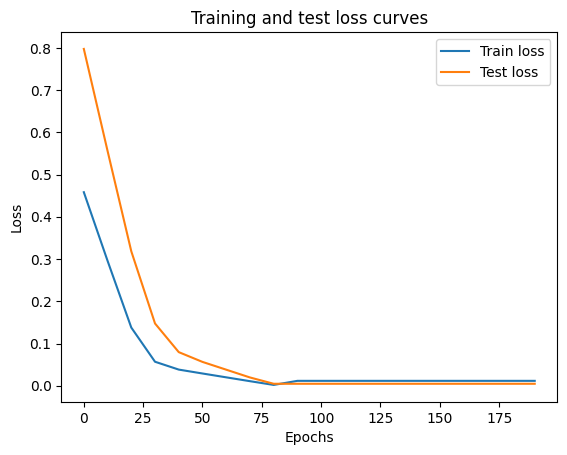

In [154]:
# Plot the loss curves
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [ ]:
with torch.inference_mode():
  y_preds_new = model_0(x_test)

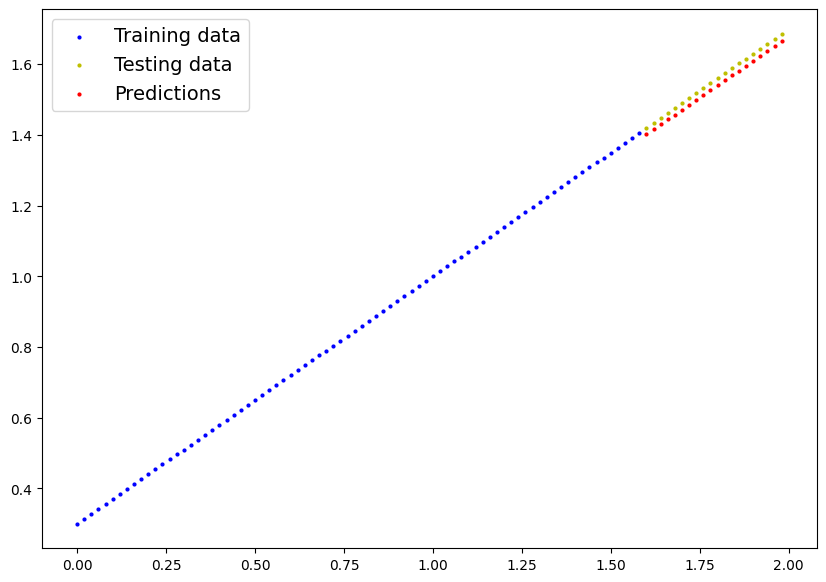

In [155]:
plot_predictions(predictions= y_preds_new)

In [157]:
# saving a model in pytorch


from pathlib import Path

#create models directory
model_path = Path("models")
model_path.mkdir(parents= True, exist_ok= True)



#create model save path
model_name = "01_pytorch.pth"  # pt or pth
model_save_path = model_path / model_name

model_save_path





PosixPath('models/01_pytorch.pth')